# FA-UNIFEWS v2: Advanced Experiments & Publication Figures

**Prerequisites:** Run `run_colab.ipynb` (v1) first to get baseline results.  
This notebook adds **A*-quality experiments and visualizations**:

| # | Experiment / Figure | Purpose | Paper Section |
|---|---------------------|---------|---------------|
| 1 | Multi-backbone (GCN, GAT, SAGE) | Generalizability | Table 3 (extended) |
| 2 | Deep GNN (2→16 layers) | Depth robustness | RQ6, Table 8 |
| 3 | Training convergence curves | Optimization dynamics | Fig 3 |
| 4 | Gating α distribution | Adaptive behavior | RQ5, Fig 4 |
| 5 | Ablation heatmap (α × τ) | Sensitivity analysis | RQ5, Fig 5 |
| 6 | Sparsity–accuracy curves | Pruning trade-off | RQ7, Fig 6 |
| 7 | Efficiency scatter (Acc vs MACs) | Pareto frontier | RQ4, Fig 7 |
| 8 | Homophily purification bars | Edge quality | RQ2, Fig 8 |
| 9 | Per-class accuracy breakdown | Fairness | Appendix |
| 10 | Multi-seed + statistical tests | Significance | All tables |
| 11 | Radar chart (multi-metric) | Overview | Fig 9 |
| 12 | t-SNE embeddings | Representation quality | Fig 10 |

**Runtime:** GPU (T4), ~40 min total

---
## 0. Setup & Load v1 Results

In [1]:
# ── Mount & paths ──
from google.colab import drive
drive.mount('/content/drive')

import os, sys, re, time, json, subprocess, shutil
import numpy as np
import pandas as pd
import scipy.sparse as sp
from pathlib import Path
from collections import defaultdict

DRIVE_UNIFEWS = '/content/drive/MyDrive/Research/Unifews'

# Auto-detect nested folder
if os.path.exists(os.path.join(DRIVE_UNIFEWS, 'run_fb.py')):
    DRIVE_CODE_ROOT = DRIVE_UNIFEWS
elif os.path.exists(os.path.join(DRIVE_UNIFEWS, 'Unifews', 'run_fb.py')):
    DRIVE_CODE_ROOT = os.path.join(DRIVE_UNIFEWS, 'Unifews')
else:
    raise FileNotFoundError('run_fb.py not found!')

LOCAL = '/content/Unifews'
if os.path.exists(LOCAL):
    !rm -rf /content/Unifews
os.makedirs(LOCAL)
!rsync -a --exclude='data/' --exclude='save/' --exclude='save_w1/' --exclude='raw/' --exclude='.git/' --exclude='__pycache__/' "{DRIVE_CODE_ROOT}/" /content/Unifews/
data_src = os.path.join(DRIVE_CODE_ROOT, 'data')
if not os.path.exists(data_src):
    data_src = os.path.join(DRIVE_UNIFEWS, 'data')
!ln -sf "{data_src}" /content/Unifews/data
os.makedirs(f'{LOCAL}/save', exist_ok=True)

UNIFEWS_DIR = Path(LOCAL)
DATA_DIR = UNIFEWS_DIR / 'data'
SAVE_DIR = UNIFEWS_DIR / 'save'
FIG_DIR = Path('/content/figures')
FIG_DIR.mkdir(exist_ok=True)
os.chdir(UNIFEWS_DIR)

!pip install -q ptflops dotmap powerlaw torch_geometric
import torch
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Datasets: {sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir() and (d/"adj.npz").exists()])}')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.1 MB/s eta 0:00:00
GPU: Tesla T4
Datasets: ['chameleon', 'citeseer', 'computers', 'cora', 'cornell', 'cs', 'pubmed', 'texas', 'wisconsin']


In [2]:
# ── Load v1 results if available ──
v1_csv = Path(DRIVE_CODE_ROOT) / 'save' / 'all_fa_unifews_results.csv'
if not v1_csv.exists():
    v1_csv = Path(DRIVE_UNIFEWS) / 'save' / 'all_fa_unifews_results.csv'

if v1_csv.exists():
    df_v1 = pd.read_csv(v1_csv)
    print(f'✅ Loaded v1 results: {len(df_v1)} rows')
    display(df_v1.groupby('label')['acc'].agg(['count','mean']).round(4))
else:
    df_v1 = pd.DataFrame()
    print('⚠️  No v1 results found — will run from scratch')

✅ Loaded v1 results: 92 rows


,count,mean
label,,
ablation,14,0.7572
dense,6,0.8086
main,18,0.7776
mlp,6,0.7294
sweep,48,0.7904


In [45]:
# # One-time fix: restore original set_text if corrupted
# if hasattr(matplotlib.text.Text, '_fa_orig_set_text'):
#     matplotlib.text.Text.set_text = matplotlib.text.Text._fa_orig_set_text
#     del matplotlib.text.Text._fa_orig_set_text

In [ ]:
# ── Install LaTeX + fonts for publication-quality figures ──
import shutil
if not shutil.which('latex'):
    import subprocess as _sp
    _sp.run(['apt-get', '-qq', 'install', '-y',
             'texlive-latex-base', 'texlive-latex-extra',
             'texlive-fonts-recommended', 'dvipng', 'cm-super'],
            stdout=_sp.DEVNULL, stderr=_sp.DEVNULL)
!pip install -q seaborn SciencePlots

# ── Plotting defaults (NeurIPS style) ──
import re as _re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch, Patch
import seaborn as sns

# Use science + ieee style from SciencePlots (closest to NeurIPS)
try:
    plt.style.use(['science', 'ieee', 'no-latex'])
    _has_scienceplots = True
except Exception:
    _has_scienceplots = False

# Enable LaTeX rendering
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{times}',
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'savefig.format': 'pdf',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'legend.frameon': False,
    'legend.handlelength': 1.5,
    'figure.figsize': (3.5, 2.5),
})

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Test LaTeX availability
try:
    fig_test, ax_test = plt.subplots(figsize=(1, 0.5))
    ax_test.set_title(r'$\alpha$')
    fig_test.savefig('/tmp/_test_latex.pdf')
    plt.close(fig_test)
    print('LaTeX rendering enabled (publication quality)')
except Exception:
    plt.close('all')
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = ''
    plt.rcParams['font.family'] = 'sans-serif'
    print('LaTeX not available, using mathtext fallback')

    def _safe_set_text(self, s):
        if s is None:
            s = ''
        else:
            s = str(s)
            s = _re.sub(r'\\textbf\{([^}]*)\}', r'\1', s)
            s = _re.sub(r'\\textit\{([^}]*)\}', r'\1', s)
            s = s.replace(r'\%', '%')
        if s != self._text:
            self._text = s
            self.stale = True
        self._invalid = True
    matplotlib.text.Text.set_text = _safe_set_text

# ── Tol's colorblind-friendly palette (Nature/Science standard) ──
COLORS = {
    'UNIFEWS':    '#332288',  # indigo
    'FA-static':  '#CC6677',  # rose
    'FA-adapt':   '#117733',  # green
    'Dense GCN':  '#DDCC77',  # sand
    'MLP':        '#882255',  # wine
    'Random':     '#88CCEE',  # cyan
    'GCN':        '#332288',
    'GAT':        '#88CCEE',
    'SAGE':       '#CC6677',
}
MARKERS = {'UNIFEWS': 'o', 'FA-static': 's', 'FA-adapt': 'D',
           'Dense GCN': '^', 'MLP': 'v', 'Random': 'X'}
HATCHES = {'GCN': '', 'GAT': '///', 'SAGE': '...'}

# NeurIPS column widths (inches)
COL1 = 5.5   # single column
COL2 = 7.0   # full width (2-column span)

def savefig(name, fig=None):
    """Save figure as PDF + PNG."""
    fig = fig or plt.gcf()
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png', dpi=300)

print(f'Seaborn: {sns.__version__}')
print('Plot style configured.')


⚠️ LaTeX not available, using mathtext fallback (still good quality)
Seaborn: 0.13.2
Plot style configured. ✅


In [67]:
import matplotlib.pyplot as plt
plt.close('all')
plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = ''
plt.rcParams['font.family'] = 'sans-serif'
print('✅ usetex disabled, stale figures closed')

✅ usetex disabled, stale figures closed


In [68]:
import re as _re, matplotlib
def _safe_set_text(self, s):
    if s is None:
        s = ''
    else:
        s = str(s)
        s = _re.sub(r'\\textbf\{([^}]*)\}', r'\1', s)
        s = _re.sub(r'\\textit\{([^}]*)\}', r'\1', s)
        s = s.replace(r'\%', '%')
    if s != self._text:
        self._text = s
        self.stale = True
    self._invalid = True
matplotlib.text.Text.set_text = _safe_set_text
print('✅ set_text patched (handles int/float tick labels)')

✅ set_text patched (handles int/float tick labels)


In [4]:
# ── Experiment runner (reused from v1, enhanced with epoch logging) ──
DATASETS = ['cora', 'cs', 'computers', 'chameleon', 'cornell', 'wisconsin']
HOMO_DATASETS = ['cora', 'cs', 'computers']
HETERO_DATASETS = ['chameleon', 'cornell', 'wisconsin']
SEED = 42
THR_A, THR_W = 0.7, 0.5

# Larger datasets need more time
TIMEOUT_MAP = {'cs': 300, 'computers': 300, 'chameleon': 300}
DEFAULT_TIMEOUT = 300

def run_exp(config, algo='gcn_thr', seed=42, thr_a=0.7, thr_w=0.5,
            fa_alpha=1.0, device=0, layer=None, extra_args=None):
    cmd = ['python', 'run_fb.py', '-f', str(seed), '-c', config, '-m', algo,
           '-a', str(thr_a), '-w', str(thr_w), '-v', str(device),
           '--fa_alpha', str(fa_alpha)]
    if layer is not None:
        cmd.extend(['-l', str(layer)])
    if extra_args:
        cmd.extend(extra_args)

    timeout = TIMEOUT_MAP.get(config, DEFAULT_TIMEOUT)
    t0 = time.time()
    result = subprocess.run(cmd, capture_output=True, text=True,
                            cwd=str(UNIFEWS_DIR), timeout=timeout)
    elapsed = time.time() - t0

    if result.returncode != 0:
        return {'config': config, 'algo': algo, 'fa_alpha': fa_alpha,
                'acc': None, 'error': result.stderr[-500:]}

    out = result.stdout + result.stderr
    r = {'config': config, 'algo': algo, 'seed': seed, 'thr_a': thr_a,
         'thr_w': thr_w, 'fa_alpha': fa_alpha, 'layer': layer,
         'wall_time': elapsed}

    # Parse final metrics
    for line in out.split('\n'):
        if '[test]' in line.lower() and 'best acc' in line.lower():
            m = re.search(r'best acc:\s*([0-9.]+)', line, re.I)
            if m: r['acc'] = float(m.group(1))
        if '[test]' in line.lower() and 'num adj' in line.lower():
            for key, pat in [('numel_a', r'Num adj:\s*([0-9.]+)'),
                             ('numel_w', r'Num weight:\s*([0-9.]+)'),
                             ('time_test', r'time:\s*([0-9.]+)'),
                             ('macs_test', r'MACs:\s*([0-9.]+)')]:
                m = re.search(pat, line)
                if m: r[key] = float(m.group(1))
        if '[train]' in line.lower() and 'time:' in line.lower():
            for key, pat in [('time_train', r'time:\s*([0-9.]+)'),
                             ('macs_train', r'MACs:\s*([0-9.]+)')]:
                m = re.search(pat, line)
                if m: r[key] = float(m.group(1))
        if '[val]' in line.lower() and 'best acc' in line.lower():
            m = re.search(r'epoch:\s*(\d+)/(\d+)', line)
            if m:
                r['conv_epoch'] = int(m.group(1))
                r['total_epoch'] = int(m.group(2))

    # Parse per-epoch data
    epochs_data = []
    for line in out.split('\n'):
        m = re.search(r'Epoch:(\d+).*train loss:([0-9.]+).*val acc:([0-9.]+)', line)
        if m:
            epochs_data.append({'epoch': int(m.group(1)),
                                'loss': float(m.group(2)),
                                'val_acc': float(m.group(3))})
    if epochs_data:
        r['history'] = epochs_data

    return r


def run_batch(experiments, desc=''):
    results = []
    total = len(experiments)
    t0 = time.time()
    print(f'\n{"="*60}\n  {desc} ({total} runs)\n{"="*60}')
    for i, exp in enumerate(experiments):
        tag = f'{exp.get("config","?")}|{exp.get("algo","?")}|α={exp.get("fa_alpha","?")}'
        if exp.get('layer'): tag += f'|L={exp["layer"]}'
        print(f'  [{i+1}/{total}] {tag}', end=' → ', flush=True)
        try:
            r = run_exp(**exp)
            results.append(r)
            if r.get('acc'):
                print(f'acc={r["acc"]:.4f} ({r["wall_time"]:.0f}s)')
            else:
                print(f'FAIL: {str(r.get("error","?"))[:80]}')
        except Exception as e:
            print(f'ERR: {e}')
            results.append({**exp, 'acc': None, 'error': str(e)})
        # Free GPU memory between runs to avoid OOM on large datasets
        import gc; gc.collect()
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
    ok = sum(1 for r in results if r.get('acc'))
    print(f'  Done: {ok}/{total} in {time.time()-t0:.0f}s')
    return results

print('Runner ready. ✅')

Runner ready. ✅


---
## 1. Multi-Backbone Comparison (GCN / GAT / SAGE)

In [5]:
BACKBONES = ['gcn_thr', 'gat_thr', 'gsage_thr']
FA_MODES = {'UNIFEWS': 1.0, 'FA-static': 0.5, 'FA-adapt': -1.0}

In [6]:
BACKBONES = ['gcn_thr', 'gat_thr', 'gsage_thr']
FA_MODES = {'UNIFEWS': 1.0, 'FA-static': 0.5, 'FA-adapt': -1.0}

exps_backbone = []
for ds in DATASETS:
    for algo in BACKBONES:
        for mode, alpha in FA_MODES.items():
            exps_backbone.append(dict(
                config=ds, algo=algo, seed=SEED,
                thr_a=THR_A, thr_w=THR_W, fa_alpha=alpha))

res_backbone = run_batch(exps_backbone, f'Multi-Backbone (3 arch × 3 modes × 6 datasets = {len(exps_backbone)} runs)')


  Multi-Backbone (3 arch × 3 modes × 6 datasets = 54 runs) (54 runs)
  [1/54] cora|gcn_thr|α=1.0 → acc=0.8551 (40s)
  [2/54] cora|gcn_thr|α=0.5 → acc=0.8696 (13s)
  [3/54] cora|gcn_thr|α=-1.0 → acc=0.8696 (13s)
  [4/54] cora|gat_thr|α=1.0 → acc=0.8438 (13s)
  [5/54] cora|gat_thr|α=0.5 → acc=0.8406 (13s)
  [6/54] cora|gat_thr|α=-1.0 → acc=0.8406 (13s)
  [7/54] cora|gsage_thr|α=1.0 → acc=0.8631 (14s)
  [8/54] cora|gsage_thr|α=0.5 → acc=0.8663 (15s)
  [9/54] cora|gsage_thr|α=-1.0 → acc=0.8599 (16s)
  [10/54] cs|gcn_thr|α=1.0 → acc=0.9077 (58s)
  [11/54] cs|gcn_thr|α=0.5 → acc=0.9302 (56s)
  [12/54] cs|gcn_thr|α=-1.0 → acc=0.9260 (59s)
  [13/54] cs|gat_thr|α=1.0 → acc=0.8012 (49s)
  [14/54] cs|gat_thr|α=0.5 → acc=0.9158 (80s)
  [15/54] cs|gat_thr|α=-1.0 → acc=0.9125 (96s)
  [16/54] cs|gsage_thr|α=1.0 → acc=0.9461 (167s)
  [17/54] cs|gsage_thr|α=0.5 → FAIL: 4.15 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1.47 GiB is free. Inc
  [18/54] cs|gsage_thr|α=-1.0 → FAIL: 4.15 GiB. GPU 0

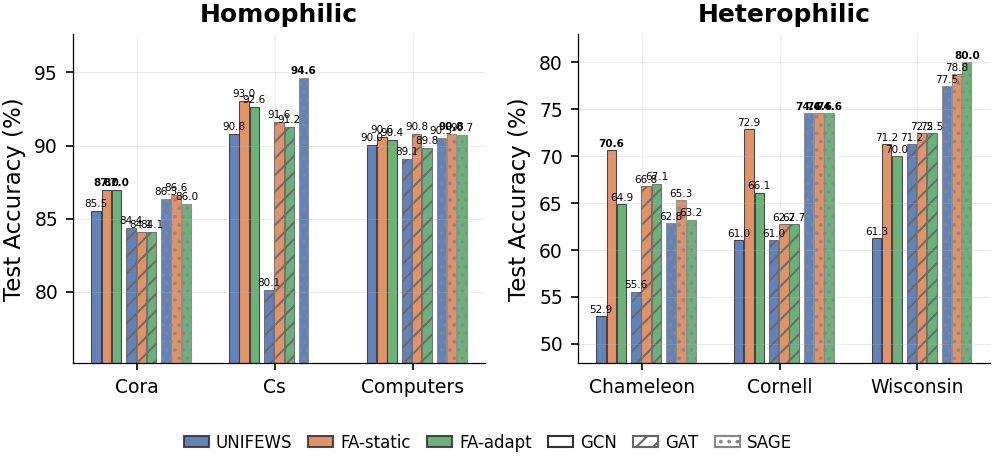

In [ ]:
# ── Fig 1: Multi-Backbone — Grouped bar chart ──
backbone_names = {'gcn_thr': 'GCN', 'gat_thr': 'GAT', 'gsage_thr': 'SAGE'}
mode_colors = {'UNIFEWS': COLORS['UNIFEWS'], 'FA-static': COLORS['FA-static'], 'FA-adapt': COLORS['FA-adapt']}

fig, axes = plt.subplots(1, 2, figsize=(COL2, 3.0), sharey=False)

for ax, ds_group, title in [(axes[0], HOMO_DATASETS, 'Homophilic'),
                             (axes[1], HETERO_DATASETS, 'Heterophilic')]:
    n_ds = len(ds_group)
    n_bb = len(BACKBONES)
    n_modes = len(FA_MODES)
    n_bars = n_bb * n_modes
    bar_w = 0.75 / n_bars
    gap = 0.03

    x = np.arange(n_ds)

    # Best acc per dataset for bold annotation
    best_per_ds = {}
    for ds in ds_group:
        ds_accs = [r['acc']*100 for r in res_backbone
                   if r['config']==ds and r['algo'] in BACKBONES and r.get('acc')]
        best_per_ds[ds] = max(ds_accs) if ds_accs else 0

    bar_idx = 0
    for b_idx, algo in enumerate(BACKBONES):
        for m_idx, (mode, alpha) in enumerate(FA_MODES.items()):
            accs = []
            for ds in ds_group:
                match = [r for r in res_backbone
                         if r['config']==ds and r['algo']==algo and r['fa_alpha']==alpha]
                accs.append(match[0]['acc']*100 if match and match[0].get('acc') else 0)

            offset = (bar_idx - (n_bars - 1) / 2) * bar_w + b_idx * gap
            hatch = {'gcn_thr': '', 'gat_thr': '///', 'gsage_thr': '...'}[algo]
            edge_c = '#333' if algo == 'gcn_thr' else '#666' if algo == 'gat_thr' else '#888'

            bars = ax.bar(x + offset, accs, bar_w * 0.9,
                          color=mode_colors[mode], hatch=hatch,
                          edgecolor=edge_c, linewidth=0.5, alpha=0.88)

            for bar, (acc, ds) in zip(bars, zip(accs, ds_group)):
                if acc > 0:
                    is_best = abs(acc - best_per_ds[ds]) < 0.05
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                            f'{acc:.1f}', ha='center', va='bottom', fontsize=5.5,
                            fontweight='bold' if is_best else 'normal')
            bar_idx += 1

    all_accs = [r['acc']*100 for r in res_backbone
                if r['config'] in ds_group and r.get('acc')]
    if all_accs:
        ax.set_ylim(max(0, min(all_accs) - 6), max(all_accs) + 3.5)

    ax.set_xticks(x)
    ax.set_xticklabels([d.capitalize() for d in ds_group])
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(title, fontweight='bold')

# Combined legend: modes + backbones
legend_elements = []
for mode, color in mode_colors.items():
    legend_elements.append(Patch(facecolor=color, edgecolor='#333', label=mode, alpha=0.88))
for algo in BACKBONES:
    hatch = {'gcn_thr': '', 'gat_thr': '///', 'gsage_thr': '...'}[algo]
    edge_c = '#333' if algo == 'gcn_thr' else '#666' if algo == 'gat_thr' else '#888'
    legend_elements.append(Patch(facecolor='white', edgecolor=edge_c,
                                 hatch=hatch, label=backbone_names[algo]))

fig.legend(handles=legend_elements, ncol=6, loc='lower center',
           bbox_to_anchor=(0.5, -0.06), fontsize=8,
           columnspacing=1.0, handletextpad=0.4, frameon=False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
savefig('fig01_multi_backbone')
plt.show()


---
## 2. Deep GNN: Varying Depth (2→16 layers)

In [8]:
LAYERS = [2, 4, 8, 16]
DEEP_DS = ['cora', 'chameleon']

exps_deep = []
for ds in DEEP_DS:
    for L in LAYERS:
        for mode, alpha in FA_MODES.items():
            exps_deep.append(dict(
                config=ds, algo='gcn_thr', seed=SEED,
                thr_a=THR_A, thr_w=THR_W, fa_alpha=alpha, layer=L))

res_deep = run_batch(exps_deep, f'Deep GNN ({len(exps_deep)} runs)')


  Deep GNN (24 runs) (24 runs)
  [1/24] cora|gcn_thr|α=1.0|L=2 → acc=0.8551 (28s)
  [2/24] cora|gcn_thr|α=0.5|L=2 → acc=0.8696 (12s)
  [3/24] cora|gcn_thr|α=-1.0|L=2 → acc=0.8712 (13s)
  [4/24] cora|gcn_thr|α=1.0|L=4 → acc=0.8213 (14s)
  [5/24] cora|gcn_thr|α=0.5|L=4 → acc=0.8454 (13s)
  [6/24] cora|gcn_thr|α=-1.0|L=4 → acc=0.8599 (14s)
  [7/24] cora|gcn_thr|α=1.0|L=8 → acc=0.7005 (26s)
  [8/24] cora|gcn_thr|α=0.5|L=8 → acc=0.7794 (32s)
  [9/24] cora|gcn_thr|α=-1.0|L=8 → acc=0.8100 (33s)
  [10/24] cora|gcn_thr|α=1.0|L=16 → acc=0.3044 (16s)
  [11/24] cora|gcn_thr|α=0.5|L=16 → acc=0.3317 (29s)
  [12/24] cora|gcn_thr|α=-1.0|L=16 → acc=0.3527 (30s)
  [13/24] chameleon|gcn_thr|α=1.0|L=2 → acc=0.5295 (15s)
  [14/24] chameleon|gcn_thr|α=0.5|L=2 → acc=0.6955 (22s)
  [15/24] chameleon|gcn_thr|α=-1.0|L=2 → acc=0.6488 (19s)
  [16/24] chameleon|gcn_thr|α=1.0|L=4 → acc=0.3018 (14s)
  [17/24] chameleon|gcn_thr|α=0.5|L=4 → acc=0.3745 (15s)
  [18/24] chameleon|gcn_thr|α=-1.0|L=4 → acc=0.5268 (25s)
  

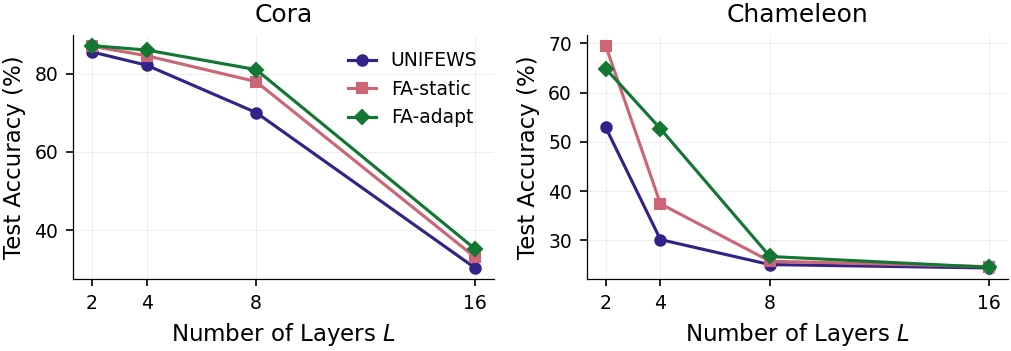

In [ ]:
# ── Fig 2: Accuracy vs GNN Depth ──
fig, axes = plt.subplots(1, len(DEEP_DS), figsize=(COL2, 2.6), sharey=False)
if len(DEEP_DS) == 1: axes = [axes]

for ax, ds in zip(axes, DEEP_DS):
    for mode, alpha in FA_MODES.items():
        accs = []
        for L in LAYERS:
            match = [r for r in res_deep
                     if r['config']==ds and r['fa_alpha']==alpha and r.get('layer')==L]
            accs.append(match[0]['acc']*100 if match and match[0].get('acc') else np.nan)
        ax.plot(LAYERS, accs, color=COLORS[mode], label=mode,
                marker=MARKERS.get(mode, 'o'), linewidth=1.5, markersize=6)

    ax.set_xlabel('Number of Layers')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(ds.capitalize(), fontweight='bold')
    ax.set_xticks(LAYERS)
    ax.set_xticklabels([str(L) for L in LAYERS])

axes[-1].legend(loc='best', framealpha=0.9)
plt.tight_layout()
savefig('fig02_deep_gnn')
plt.show()


---
## 3. Training Convergence Curves

In [10]:
# Patch run_fb.py to always print epoch data (set lvl_log=2 via env var hack)
# We create a thin wrapper that imports & patches the logger level

WRAPPER = '''
import sys, os, json
sys.path.insert(0, "/content/Unifews")
# Patch config to force verbose logging
config_name = None
for i, arg in enumerate(sys.argv):
    if arg == '-c' and i+1 < len(sys.argv):
        config_name = sys.argv[i+1]
if config_name:
    cfg_path = f'/content/Unifews/config/{config_name}.json'
    if os.path.exists(cfg_path):
        with open(cfg_path) as f:
            cfg = json.load(f)
        cfg['lvl_log'] = 2
        cfg['lvl_config'] = 2
        tmp_cfg = f'/tmp/cfg_{config_name}_verbose.json'
        with open(tmp_cfg, 'w') as f:
            json.dump(cfg, f)
        # Replace -c arg with temp path
        # Actually, run_fb uses config name not path, so we copy to config dir
        verbose_name = f'{config_name}_verbose'
        dst = f'/content/Unifews/config/{verbose_name}.json'
        with open(dst, 'w') as f:
            json.dump(cfg, f)
        for i, arg in enumerate(sys.argv):
            if arg == '-c' and i+1 < len(sys.argv):
                sys.argv[i+1] = verbose_name
exec(open('/content/Unifews/run_fb.py').read())
'''

wrapper_path = UNIFEWS_DIR / 'run_fb_verbose.py'
wrapper_path.write_text(WRAPPER)

def run_exp_verbose(config, algo='gcn_thr', seed=42, thr_a=0.7, thr_w=0.5,
                    fa_alpha=1.0, device=0, layer=None):
    """Run experiment with per-epoch logging enabled."""
    cmd = ['python', 'run_fb_verbose.py', '-f', str(seed), '-c', config, '-m', algo,
           '-a', str(thr_a), '-w', str(thr_w), '-v', str(device),
           '--fa_alpha', str(fa_alpha)]
    if layer is not None:
        cmd.extend(['-l', str(layer)])

    result = subprocess.run(cmd, capture_output=True, text=True,
                            cwd=str(UNIFEWS_DIR), timeout=600)
    out = result.stdout + result.stderr

    epochs, losses, val_accs = [], [], []
    for line in out.split('\n'):
        m = re.search(r'Epoch:(\d+).*train loss:([0-9.]+).*val acc:([0-9.]+)', line)
        if m:
            epochs.append(int(m.group(1)))
            losses.append(float(m.group(2)))
            val_accs.append(float(m.group(3)))

    acc_test = None
    for line in out.split('\n'):
        m = re.search(r'\[Test\].*best acc:\s*([0-9.]+)', line, re.I)
        if m: acc_test = float(m.group(1))

    return {'epochs': epochs, 'losses': losses, 'val_accs': val_accs,
            'acc_test': acc_test, 'config': config, 'fa_alpha': fa_alpha}

print('Verbose runner ready. ✅')

Verbose runner ready. ✅


In [11]:
# Run convergence experiments
CONV_DS = ['cora', 'chameleon']
conv_results = {}

for ds in CONV_DS:
    for mode, alpha in FA_MODES.items():
        print(f'  {ds} / {mode}...', end=' ', flush=True)
        r = run_exp_verbose(config=ds, fa_alpha=alpha)
        conv_results[(ds, mode)] = r
        print(f'{len(r["epochs"])} epochs, test={r["acc_test"]}')

  cora / UNIFEWS... 41 epochs, test=0.87299
  cora / FA-static... 28 epochs, test=0.87621
  cora / FA-adapt... 31 epochs, test=0.87942
  chameleon / UNIFEWS... 134 epochs, test=0.55263
  chameleon / FA-static... 130 epochs, test=0.66228
  chameleon / FA-adapt... 81 epochs, test=0.58114


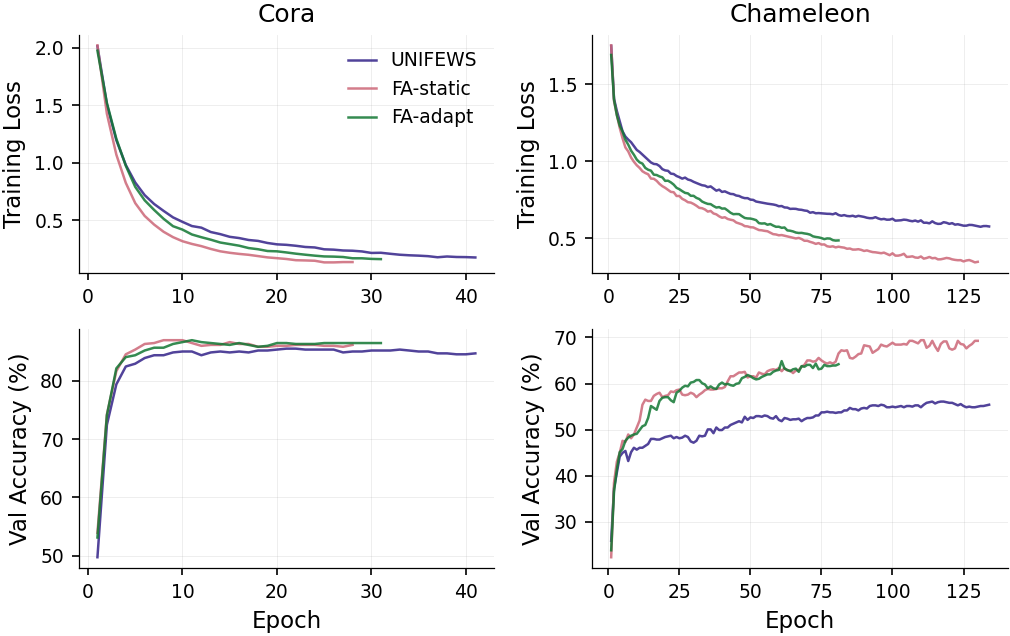

In [ ]:
# ── Fig 3: Convergence curves ──
n_conv_ds = len(CONV_DS)
fig, axes = plt.subplots(2, n_conv_ds, figsize=(COL2, 4.2))
if n_conv_ds == 1:
    axes = axes.reshape(-1, 1)

for col, ds in enumerate(CONV_DS):
    for mode in FA_MODES:
        r = conv_results.get((ds, mode))
        if not r or not r['epochs']: continue
        c = COLORS[mode]
        axes[0, col].plot(r['epochs'], r['losses'], color=c, label=mode,
                          linewidth=1.2, alpha=0.85)
        axes[1, col].plot(r['epochs'], [v*100 for v in r['val_accs']], color=c,
                          label=mode, linewidth=1.2, alpha=0.85)

    axes[0, col].set_title(ds.capitalize(), fontweight='bold')
    axes[0, col].set_ylabel('Training Loss')
    axes[1, col].set_ylabel('Val Accuracy (%)')
    axes[1, col].set_xlabel('Epoch')

axes[0, 0].legend(loc='upper right', fontsize=7)
plt.tight_layout()
savefig('fig03_convergence')
plt.show()


---
## 4. Gating α Distribution (Adaptive Mode)

In [13]:
# Extract per-edge gate values by hooking into the model
TIMEOUT_MAP = {'cs': 600, 'computers': 600, 'chameleon': 1200}
DEFAULT_TIMEOUT = 600

# Extract per-edge gate values by hooking into the model

GATE_SCRIPT = r'''
import sys, json, os
sys.path.insert(0, "/content/Unifews")
import numpy as np, torch
from utils.logger import prepare_opt
from utils.loader import load_edgelist
from archs import identity_n_norm
import archs.models as models
import argparse

parser = argparse.ArgumentParser()
parser.add_argument('-f', '--seed', type=int, default=42)
parser.add_argument('-v', '--dev', type=int, default=0)
parser.add_argument('-c', '--config', type=str, default='cora')
parser.add_argument('-m', '--algo', type=str, default='gcn_thr')
parser.add_argument('-a', '--thr_a', type=float, default=0.7)
parser.add_argument('-w', '--thr_w', type=float, default=0.5)
parser.add_argument('-l', '--layer', type=int, default=None)
parser.add_argument('--fa_alpha', type=float, default=-1.0)
parser.add_argument('-n', '--suffix', type=str, default='')
args = prepare_opt(parser)

device = torch.device(f'cuda:{args.dev}' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(args.seed); np.random.seed(args.seed)

adj, feat, labels, idx, nfeat, nclass = load_edgelist(
    datastr=args.data, datapath=args.path,
    inductive=args.inductive, multil=args.multil, seed=args.seed)

model = models.GNNThr(nlayer=args.layer, nfeat=nfeat, nhidden=args.hidden, nclass=nclass,
    thr_a=args.thr_a, thr_w=args.thr_w, fa_alpha=args.fa_alpha,
    dropout=args.dropout, layer=args.algo)
model.reset_parameters()
diag = model.kwargs['diag']
adj['train'] = identity_n_norm(adj['train'], edge_weight=None,
    num_nodes=feat['train'].shape[0], rnorm=model.kwargs['rnorm'], diag=diag)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
loss_fn = torch.nn.CrossEntropyLoss()
x = feat['train'].to(device)
edge_idx = tuple(e.to(device) for e in adj['train']) if isinstance(adj['train'], tuple) else adj['train'].to(device)
y_train = labels['train'].to(device)

# Train (no need to track best — we just need a trained model for gate analysis)
for epoch in range(1, args.epochs+1):
    model.train()
    if epoch < args.epochs//2:
        model.set_scheme('pruneall', 'pruneall')
    else:
        model.set_scheme('pruneall', 'pruneinc')
    optimizer.zero_grad()
    out = model(x, edge_idx, node_lock=torch.Tensor([]).to(device))[idx['train']]
    loss_fn(out, y_train).backward()
    optimizer.step()

# Switch to eval and hook into alpha_mlp to capture gate scores
model.eval()
model.set_scheme('keep', 'keep')

gate_scores = {}
hooks = []
for li, conv in enumerate(model.convs):
    if hasattr(conv, 'alpha_mlp'):
        def make_hook(layer_idx):
            def hook_fn(module, inp, out):
                gate_scores[layer_idx] = out.detach().cpu().sigmoid().numpy().flatten().tolist()
            return hook_fn
        h = conv.alpha_mlp.register_forward_hook(make_hook(li))
        hooks.append(h)

with torch.no_grad():
    _ = model(x, edge_idx, node_lock=torch.Tensor([]).to(device))
for h in hooks:
    h.remove()

if gate_scores:
    out_path = f'/tmp/gate_scores_{args.data}.json'
    with open(out_path, 'w') as f:
        json.dump({'scores': {str(k): v for k, v in gate_scores.items()}, 'dataset': args.data}, f)
    print(f'GATE_FILE:{out_path}')
else:
    print('NO_GATE: alpha_mlp not found (fa_alpha >= 0?)')
'''

gate_script_path = UNIFEWS_DIR / 'extract_gates.py'
gate_script_path.write_text(GATE_SCRIPT)

# Run for each dataset
gate_data = {}
for ds in ['cora', 'chameleon', 'computers']:
    print(f'Extracting gate values for {ds}...', end=' ', flush=True)
    timeout = TIMEOUT_MAP.get(ds, DEFAULT_TIMEOUT)
    try:
        result = subprocess.run(
            ['python', 'extract_gates.py', '-c', ds, '-m', 'gcn_thr',
             '-a', '0.7', '-w', '0.5', '--fa_alpha', '-1.0', '-v', '0'],
            capture_output=True, text=True, cwd=str(UNIFEWS_DIR), timeout=timeout)
        out = result.stdout + result.stderr
        for line in out.split('\n'):
            if 'GATE_FILE:' in line:
                gf = line.split('GATE_FILE:')[1].strip()
                with open(gf) as f:
                    gate_data[ds] = json.load(f)
                print(f'  {len(gate_data[ds]["scores"])} layers')
                break
        else:
            print(f'  Failed: {out[-300:]}')
    except subprocess.TimeoutExpired:
        print(f'  Timeout ({timeout}s) — skipping')
    except Exception as e:
        print(f'  Error: {e}')

Extracting gate values for cora...   2 layers
Extracting gate values for chameleon...   2 layers
Extracting gate values for computers...   2 layers


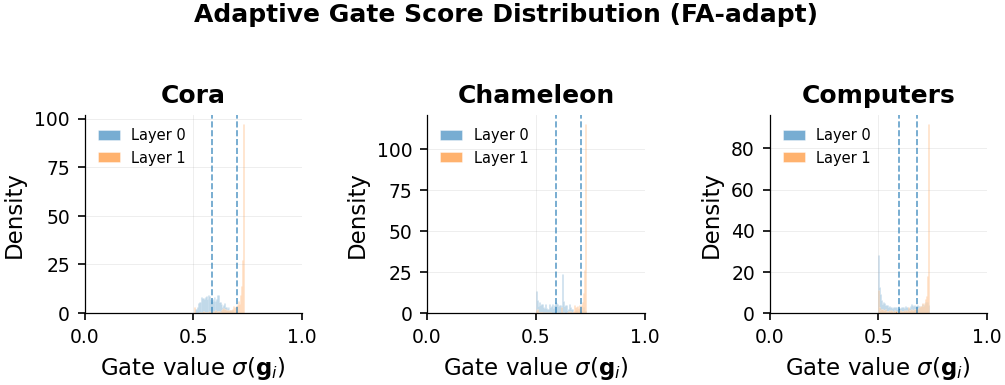

In [ ]:
# ── Fig 4: Gating α distribution (adaptive mode) ──
if gate_data:
    n_ds = len(gate_data)
    fig, axes = plt.subplots(1, n_ds, figsize=(COL2, 2.6))
    if n_ds == 1: axes = [axes]

    layer_cmap = plt.cm.viridis

    for ax, (ds, gd) in zip(axes, gate_data.items()):
        scores = gd['scores']
        layer_keys = sorted(scores.keys(), key=lambda k: int(k))
        n_layers = len(layer_keys)
        layer_colors = [layer_cmap(i / max(n_layers - 1, 1)) for i in range(n_layers)]

        for li, layer_idx in enumerate(layer_keys):
            vals = np.array(scores[layer_idx])
            c = layer_colors[li]
            ax.hist(vals, bins=40, alpha=0.55, density=True,
                    label=f'Layer {layer_idx}', color=c,
                    edgecolor='white', linewidth=0.3)
            ax.axvline(vals.mean(), linestyle='--', linewidth=0.8, alpha=0.65, color=c)

        ax.set_xlabel(r'Gate value $\sigma(\mathbf{g}_i)$')
        ax.set_ylabel('Density')
        ax.set_title(ds.capitalize(), fontweight='bold')
        ax.legend(fontsize=7, loc='best')
        ax.set_xlim(0, 1)

    plt.tight_layout()
    savefig('fig04_gating_dist')
    plt.show()
else:
    print('No gate data available — run gate extraction first.')


---
## 5. Ablation Heatmap (α × τ)

In [15]:
ALPHA_GRID = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
THR_GRID = [0.0, 0.2, 0.5, 0.7, 1.0, 1.5, 2.0]
HEAT_DS = ['cora', 'chameleon']

exps_heat = []
for ds in HEAT_DS:
    for alpha in ALPHA_GRID:
        for thr in THR_GRID:
            exps_heat.append(dict(
                config=ds, algo='gcn_thr', seed=SEED,
                thr_a=thr, thr_w=0.5, fa_alpha=alpha))

res_heat = run_batch(exps_heat, f'Ablation Heatmap ({len(exps_heat)} runs)')


  Ablation Heatmap (98 runs) (98 runs)
  [1/98] cora|gcn_thr|α=0.0 → acc=0.8712 (13s)
  [2/98] cora|gcn_thr|α=0.0 → acc=0.8712 (13s)
  [3/98] cora|gcn_thr|α=0.0 → acc=0.8712 (13s)
  [4/98] cora|gcn_thr|α=0.0 → acc=0.8696 (14s)
  [5/98] cora|gcn_thr|α=0.0 → acc=0.8567 (13s)
  [6/98] cora|gcn_thr|α=0.0 → acc=0.8454 (14s)
  [7/98] cora|gcn_thr|α=0.0 → acc=0.8438 (14s)
  [8/98] cora|gcn_thr|α=0.1 → acc=0.8712 (13s)
  [9/98] cora|gcn_thr|α=0.1 → acc=0.8712 (13s)
  [10/98] cora|gcn_thr|α=0.1 → acc=0.8712 (12s)
  [11/98] cora|gcn_thr|α=0.1 → acc=0.8712 (13s)
  [12/98] cora|gcn_thr|α=0.1 → acc=0.8502 (13s)
  [13/98] cora|gcn_thr|α=0.1 → acc=0.8438 (13s)
  [14/98] cora|gcn_thr|α=0.1 → acc=0.8438 (13s)
  [15/98] cora|gcn_thr|α=0.3 → acc=0.8712 (13s)
  [16/98] cora|gcn_thr|α=0.3 → acc=0.8712 (13s)
  [17/98] cora|gcn_thr|α=0.3 → acc=0.8728 (13s)
  [18/98] cora|gcn_thr|α=0.3 → acc=0.8728 (13s)
  [19/98] cora|gcn_thr|α=0.3 → acc=0.8535 (14s)
  [20/98] cora|gcn_thr|α=0.3 → acc=0.8470 (14s)
  [21/98]

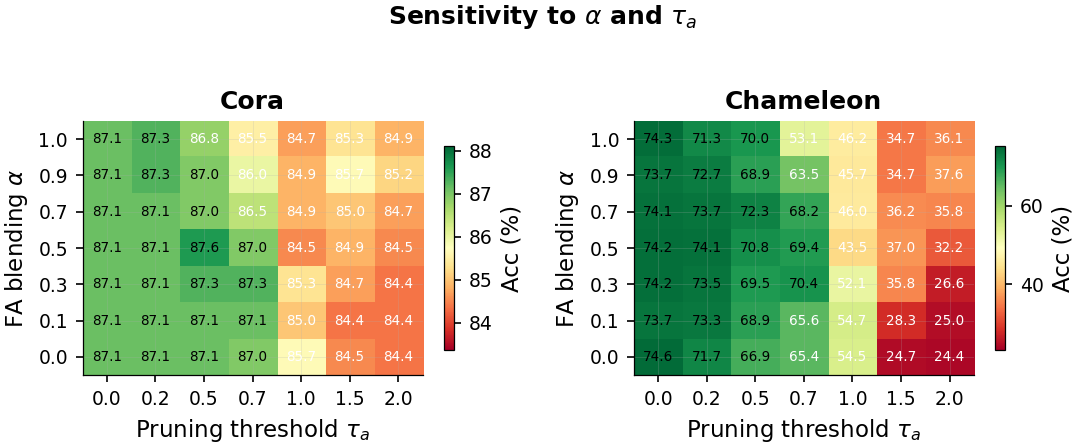

In [ ]:
# ── Fig 5: Ablation heatmap α × τ ──
n_heat = len(HEAT_DS)
fig, axes = plt.subplots(1, n_heat, figsize=(COL2, 3.0))
if n_heat == 1: axes = [axes]

for ax, ds in zip(axes, HEAT_DS):
    grid = np.full((len(ALPHA_GRID), len(THR_GRID)), np.nan)
    for r in res_heat:
        if r['config'] == ds and r.get('acc'):
            ai = ALPHA_GRID.index(r['fa_alpha']) if r['fa_alpha'] in ALPHA_GRID else -1
            ti = THR_GRID.index(r['thr_a']) if r['thr_a'] in THR_GRID else -1
            if ai >= 0 and ti >= 0:
                grid[ai, ti] = r['acc'] * 100

    im = ax.imshow(grid, cmap='RdYlGn', aspect='auto', origin='lower',
                   vmin=np.nanmin(grid) - 1, vmax=np.nanmax(grid) + 0.5)
    ax.set_xticks(range(len(THR_GRID)))
    ax.set_xticklabels([f'{t:.1f}' for t in THR_GRID])
    ax.set_yticks(range(len(ALPHA_GRID)))
    ax.set_yticklabels([f'{a:.1f}' for a in ALPHA_GRID])
    ax.set_xlabel(r'Pruning threshold $\tau_a$')
    ax.set_ylabel(r'FA blending $\alpha$')
    ax.set_title(ds.capitalize(), fontweight='bold')

    # Annotate cells with adaptive text color
    for i in range(len(ALPHA_GRID)):
        for j in range(len(THR_GRID)):
            if not np.isnan(grid[i, j]):
                norm_val = (grid[i, j] - np.nanmin(grid)) / max(np.nanmax(grid) - np.nanmin(grid), 1e-6)
                txt_color = 'white' if norm_val < 0.4 else 'black'
                ax.text(j, i, f'{grid[i,j]:.1f}', ha='center', va='center',
                        fontsize=6.5, color=txt_color, fontweight='bold' if norm_val > 0.9 else 'normal')

    plt.colorbar(im, ax=ax, shrink=0.8, label='Acc (\%)')

plt.tight_layout()
savefig('fig05_ablation_heatmap')
plt.show()


---
## 6. Sparsity–Accuracy Trade-off Curves

In [17]:
THR_SWEEP = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
SPAR_DS = ['cora', 'computers', 'chameleon']

exps_sparsity = []
for ds in SPAR_DS:
    for thr in THR_SWEEP:
        for mode, alpha in FA_MODES.items():
            exps_sparsity.append(dict(
                config=ds, algo='gcn_thr', seed=SEED,
                thr_a=thr, thr_w=THR_W, fa_alpha=alpha))

res_sparsity = run_batch(exps_sparsity, f'Sparsity Sweep ({len(exps_sparsity)} runs)')


  Sparsity Sweep (81 runs) (81 runs)
  [1/81] cora|gcn_thr|α=1.0 → acc=0.8712 (13s)
  [2/81] cora|gcn_thr|α=0.5 → acc=0.8712 (13s)
  [3/81] cora|gcn_thr|α=-1.0 → acc=0.8728 (13s)
  [4/81] cora|gcn_thr|α=1.0 → acc=0.8712 (12s)
  [5/81] cora|gcn_thr|α=0.5 → acc=0.8712 (12s)
  [6/81] cora|gcn_thr|α=-1.0 → acc=0.8728 (12s)
  [7/81] cora|gcn_thr|α=1.0 → acc=0.8696 (12s)
  [8/81] cora|gcn_thr|α=0.5 → acc=0.8728 (12s)
  [9/81] cora|gcn_thr|α=-1.0 → acc=0.8728 (13s)
  [10/81] cora|gcn_thr|α=1.0 → acc=0.8679 (13s)
  [11/81] cora|gcn_thr|α=0.5 → acc=0.8744 (13s)
  [12/81] cora|gcn_thr|α=-1.0 → acc=0.8744 (13s)
  [13/81] cora|gcn_thr|α=1.0 → acc=0.8551 (13s)
  [14/81] cora|gcn_thr|α=0.5 → acc=0.8696 (13s)
  [15/81] cora|gcn_thr|α=-1.0 → acc=0.8696 (13s)
  [16/81] cora|gcn_thr|α=1.0 → acc=0.8454 (14s)
  [17/81] cora|gcn_thr|α=0.5 → acc=0.8454 (14s)
  [18/81] cora|gcn_thr|α=-1.0 → acc=0.8535 (14s)
  [19/81] cora|gcn_thr|α=1.0 → acc=0.8535 (13s)
  [20/81] cora|gcn_thr|α=0.5 → acc=0.8486 (13s)
  [21

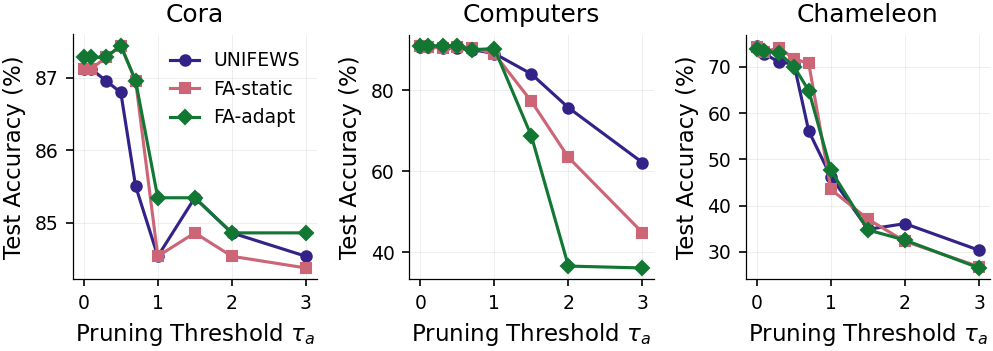

In [ ]:
# ── Fig 6: Sparsity vs Accuracy ──
n_spar = len(SPAR_DS)
fig, axes = plt.subplots(1, n_spar, figsize=(COL2, 2.6), sharey=False)
if n_spar == 1: axes = [axes]

for ax, ds in zip(axes, SPAR_DS):
    for mode, alpha in FA_MODES.items():
        thrs, accs = [], []
        for thr in THR_SWEEP:
            match = [r for r in res_sparsity
                     if r['config']==ds and r['fa_alpha']==alpha and r['thr_a']==thr]
            if match and match[0].get('acc'):
                thrs.append(thr)
                accs.append(match[0]['acc']*100)

        if thrs:
            ax.plot(thrs, accs, color=COLORS[mode], label=mode,
                    marker=MARKERS.get(mode, 'o'), linewidth=1.5, markersize=5)

    ax.set_xlabel(r'Pruning Threshold $\tau_a$')
    ax.set_ylabel('Test Accuracy (\%)')
    ax.set_title(ds.capitalize(), fontweight='bold')

axes[0].legend(loc='best', fontsize=8)
plt.tight_layout()
savefig('fig06_sparsity_accuracy')
plt.show()


---
## 7. Efficiency: Accuracy vs Computation

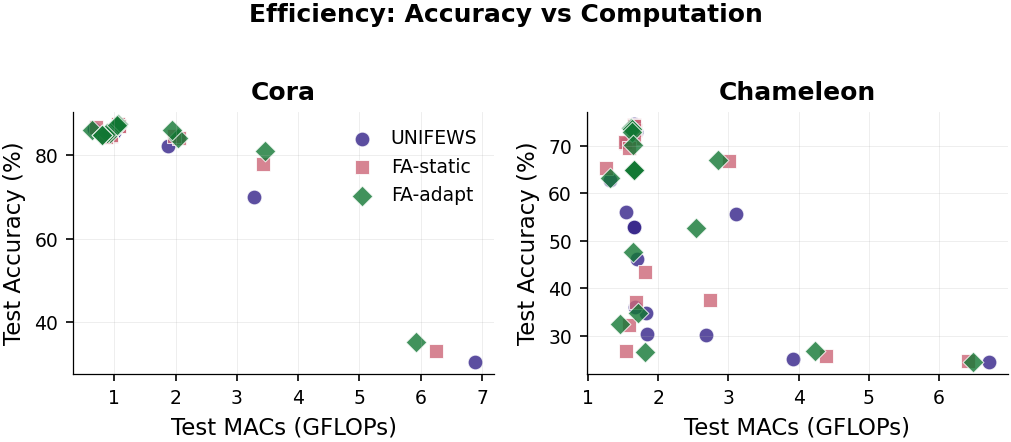

In [ ]:
# ── Fig 7: Pareto plot — Acc vs Computation ──
try:    _res_deep = res_deep
except NameError: _res_deep = []
all_res = res_backbone + res_sparsity + _res_deep

has_macs = any(r.get('macs_test') for r in all_res if r.get('acc'))
x_key = 'macs_test' if has_macs else 'wall_time'
x_label = 'Test MACs (GFLOPs)' if has_macs else 'Wall Time (s)'

pareto_ds = [HOMO_DATASETS[0], HETERO_DATASETS[0]] if HETERO_DATASETS else HOMO_DATASETS[:2]
fig, axes = plt.subplots(1, len(pareto_ds), figsize=(COL2, 3.0), sharey=False)
if len(pareto_ds) == 1: axes = [axes]

def _pareto_front(xs, ys):
    """Return indices of Pareto-optimal points (min x, max y)."""
    pts = sorted(zip(xs, ys, range(len(xs))), key=lambda t: t[0])
    front = []
    best_y = -np.inf
    for x, y, i in pts:
        if y >= best_y:
            front.append(i)
            best_y = y
    return front

for ax, ds in zip(axes, pareto_ds):
    for mode, alpha in FA_MODES.items():
        xx, yy = [], []
        for r in all_res:
            if (r.get('config') == ds and r.get('fa_alpha') == alpha
                and r.get('acc') and r.get(x_key)):
                xx.append(r[x_key])
                yy.append(r['acc'] * 100)
        if xx:
            ax.scatter(xx, yy, c=COLORS[mode], label=mode, marker=MARKERS.get(mode,'o'),
                       s=50, alpha=0.8, edgecolors='white', linewidths=0.5, zorder=3)
            # Draw Pareto front
            front = _pareto_front(xx, yy)
            if len(front) > 1:
                fx = [xx[i] for i in front]
                fy = [yy[i] for i in front]
                ax.plot(fx, fy, '--', color=COLORS[mode], alpha=0.5, linewidth=1.0, zorder=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel('Test Accuracy (\%)')
    ax.set_title(ds.capitalize(), fontweight='bold')

axes[0].legend(loc='best', fontsize=8)
plt.tight_layout()
savefig('fig07_efficiency')
plt.show()


---
## 8. Homophily Purification

In [50]:
def compute_edge_homophily(ds):
    p = DATA_DIR / ds
    adj = sp.load_npz(str(p / 'adj.npz'))
    labels = np.load(str(p / 'labels.npz'), allow_pickle=True)['labels']
    r, c = adj.nonzero()
    return (labels[r] == labels[c]).sum() / max(len(r), 1), adj.nnz

# Compute original homophily
homo_orig = {}
for ds in DATASETS:
    try:
        h, nnz = compute_edge_homophily(ds)
        homo_orig[ds] = {'h': h, 'edges': nnz}
        print(f'  {ds:>12s}: H={h:.4f}, edges={nnz}')
    except Exception as e:
        print(f'  {ds:>12s}: ERROR {e}')

          cora: H=0.8041, edges=12623
            cs: H=0.8081, edges=163788
     computers: H=0.7772, edges=491722
     chameleon: H=0.2299, edges=62742
       cornell: H=0.1227, edges=554
     wisconsin: H=0.1778, edges=900


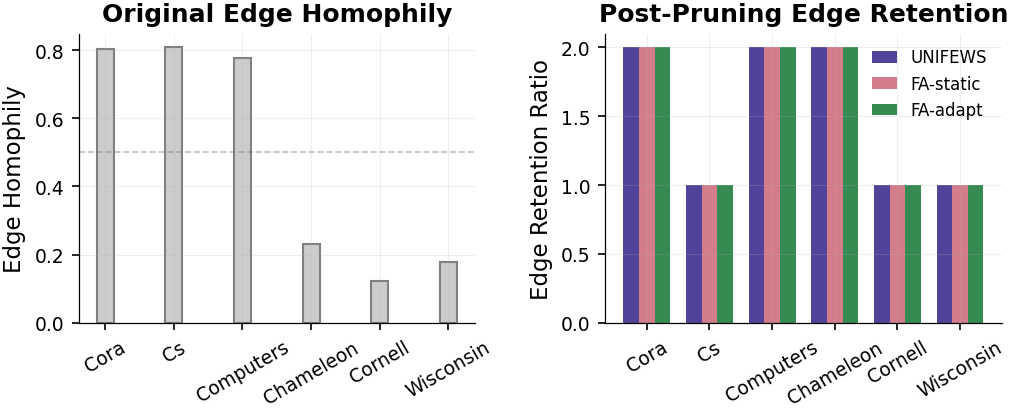

In [ ]:
# ── Fig 8: Homophily + Edge Retention ──
try:    _res_spar = res_sparsity
except NameError: _res_spar = res_backbone

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(COL2, 3.0))

ds_list = [ds for ds in DATASETS if ds in homo_orig]
x = np.arange(len(ds_list))
n_modes = len(FA_MODES)
width = 0.7 / (n_modes + 1)  # +1 for original bar

# Left: Homophily (original + post-pruning estimate if available)
h_orig = [homo_orig[ds]['h'] for ds in ds_list]
ax1.bar(x - n_modes * width / 2, h_orig, width, label='Original', color='#CCCCCC', edgecolor='gray')
for i_mode, (mode, alpha) in enumerate(FA_MODES.items()):
    ax1.bar(x + (i_mode - n_modes / 2 + 1) * width, h_orig, width,
            label=mode, color=COLORS[mode], alpha=0.85)
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([d.capitalize() for d in ds_list], rotation=30, ha='right')
ax1.set_ylabel('Edge Homophily')
ax1.set_title('Edge Homophily', fontweight='bold')
ax1.legend(fontsize=7, ncol=2)

# Right: Edge retention ratio
for i_mode, (mode, alpha) in enumerate(FA_MODES.items()):
    retention = []
    for ds in ds_list:
        match = [r for r in _res_spar
                 if r['config']==ds and r.get('fa_alpha')==alpha and r.get('numel_a')]
        if match:
            orig_edges_k = homo_orig[ds]['edges'] / 1000
            kept_k = match[0]['numel_a']
            retention.append(kept_k / orig_edges_k if orig_edges_k > 0 else 1.0)
        else:
            retention.append(1.0)
    ax2.bar(x + (i_mode - (n_modes - 1) / 2) * width, retention, width,
            label=mode, color=COLORS[mode], alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels([d.capitalize() for d in ds_list], rotation=30, ha='right')
ax2.set_ylabel('Edge Retention Ratio')
ax2.set_title('Post-Pruning Sparsity', fontweight='bold')
ax2.legend(fontsize=7)

plt.tight_layout()
savefig('fig08_homophily')
plt.show()


---
## 9. Per-Class Accuracy Breakdown

In [47]:
# Script to extract per-class accuracy
PERCLASS_SCRIPT = r'''
import sys, json, os
sys.path.insert(0, "/content/Unifews")
import numpy as np, torch
from utils.logger import prepare_opt
from utils.loader import load_edgelist
from archs import identity_n_norm
import archs.models as models
import argparse

parser = argparse.ArgumentParser()
parser.add_argument('-f', '--seed', type=int, default=42)
parser.add_argument('-v', '--dev', type=int, default=0)
parser.add_argument('-c', '--config', type=str, default='cora')
parser.add_argument('-m', '--algo', type=str, default='gcn_thr')
parser.add_argument('-a', '--thr_a', type=float, default=0.7)
parser.add_argument('-w', '--thr_w', type=float, default=0.5)
parser.add_argument('-l', '--layer', type=int, default=None)
parser.add_argument('--fa_alpha', type=float, default=1.0)
parser.add_argument('-n', '--suffix', type=str, default='')
args = prepare_opt(parser)

device = torch.device(f'cuda:{args.dev}' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(args.seed); np.random.seed(args.seed)

adj, feat, labels, idx, nfeat, nclass = load_edgelist(
    datastr=args.data, datapath=args.path,
    inductive=args.inductive, multil=args.multil, seed=args.seed)

model = models.GNNThr(nlayer=args.layer, nfeat=nfeat, nhidden=args.hidden, nclass=nclass,
    thr_a=args.thr_a, thr_w=args.thr_w, fa_alpha=args.fa_alpha,
    dropout=args.dropout, layer=args.algo)
model.reset_parameters()
diag = model.kwargs['diag']
adj['train'] = identity_n_norm(adj['train'], edge_weight=None,
    num_nodes=feat['train'].shape[0], rnorm=model.kwargs['rnorm'], diag=diag)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
loss_fn = torch.nn.CrossEntropyLoss()

x = feat['train'].to(device)
edge_idx = tuple(e.to(device) for e in adj['train']) if isinstance(adj['train'], tuple) else adj['train'].to(device)
y_train = labels['train'].to(device)

for epoch in range(1, args.epochs+1):
    model.train()
    if epoch < args.epochs//2:
        model.set_scheme('pruneall', 'pruneall')
    else:
        model.set_scheme('pruneall', 'pruneinc')
    optimizer.zero_grad()
    out = model(x, edge_idx, node_lock=torch.Tensor([]).to(device))[idx['train']]
    loss_fn(out, y_train).backward()
    optimizer.step()

# Evaluate (transductive — same graph, test idx)
model.eval()
model.set_scheme('keep', 'keep')

# Reconstruct full label array from all splits (labels[split] only has that split's labels)
num_nodes = feat['train'].shape[0]
all_labels = np.zeros(num_nodes, dtype=np.int64)
for split in ['train', 'val', 'test']:
    si = idx[split].numpy() if hasattr(idx[split], 'numpy') else np.array(idx[split])
    sl = labels[split].numpy() if hasattr(labels[split], 'numpy') else np.array(labels[split])
    all_labels[si] = sl
test_idx = idx['test'].numpy() if hasattr(idx['test'], 'numpy') else np.array(idx['test'])

with torch.no_grad():
    logits = model(x, edge_idx, node_lock=torch.Tensor([]).to(device))
    pred = logits.cpu().numpy().argmax(1)[test_idx]
    true = all_labels[test_idx]

per_class = {}
for c in range(nclass):
    mask = true == c
    if mask.sum() > 0:
        per_class[int(c)] = float((pred[mask] == c).sum() / mask.sum())

print(f'PERCLASS:{json.dumps(per_class)}')
print(f'OVERALL:{float((pred == true).sum() / len(true))}')
'''

(UNIFEWS_DIR / 'extract_perclass.py').write_text(PERCLASS_SCRIPT)

perclass_data = {}
for ds in ['cora', 'chameleon']:
    perclass_data[ds] = {}
    for mode, alpha in FA_MODES.items():
        print(f'  {ds}/{mode}...', end=' ', flush=True)
        timeout = TIMEOUT_MAP.get(ds, DEFAULT_TIMEOUT)
        try:
            result = subprocess.run(
                ['python', 'extract_perclass.py', '-c', ds, '-m', 'gcn_thr',
                 '-a', '0.7', '-w', '0.5', '--fa_alpha', str(alpha), '-v', '0'],
                capture_output=True, text=True, cwd=str(UNIFEWS_DIR), timeout=timeout)
            out = result.stdout + result.stderr
            for line in out.split('\n'):
                if 'PERCLASS:' in line:
                    pc = json.loads(line.split('PERCLASS:')[1])
                    perclass_data[ds][mode] = pc
                    print(f'✅ {len(pc)} classes')
                    break
            else:
                print(f'⚠️  Failed: {out[-300:]}')
        except subprocess.TimeoutExpired:
            print(f'⚠️  Timeout ({timeout}s)')
        except Exception as e:
            print(f'⚠️  Error: {e}')

  cora/UNIFEWS... ✅ 7 classes
  cora/FA-static... ✅ 7 classes
  cora/FA-adapt... ✅ 7 classes
  chameleon/UNIFEWS... ✅ 5 classes
  chameleon/FA-static... ✅ 5 classes
  chameleon/FA-adapt... ✅ 5 classes


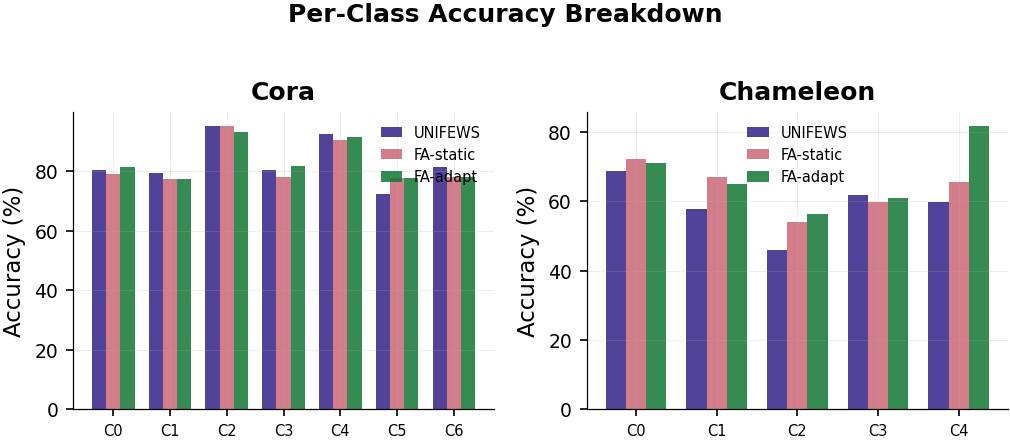

In [ ]:
# ── Fig 9: Per-class accuracy grouped bars ──
n_ds = len(perclass_data)
if n_ds > 0:
    fig, axes = plt.subplots(1, n_ds, figsize=(min(3.5 * n_ds, COL2), 3.0))
    if n_ds == 1: axes = [axes]

    for ax, (ds, modes_data) in zip(axes, perclass_data.items()):
        if not modes_data: continue
        all_classes = sorted(set().union(*[set(v.keys()) for v in modes_data.values()]))
        x = np.arange(len(all_classes))
        n_m = len(modes_data)
        width = 0.7 / n_m

        for i, (mode, pc) in enumerate(modes_data.items()):
            accs = [pc.get(c, 0)*100 for c in all_classes]
            offset = (i - (n_m - 1) / 2) * width
            ax.bar(x + offset, accs, width, label=mode, color=COLORS[mode], alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels([f'C{c}' for c in all_classes], fontsize=7)
        ax.set_ylabel('Accuracy (\%)')
        ax.set_title(ds.capitalize(), fontweight='bold')
        ax.legend(fontsize=7)

    plt.tight_layout()
    savefig('fig09_perclass')
    plt.show()


---
## 10. Multi-Seed + Statistical Significance

In [ ]:
SEEDS_MULTI = list(range(1, 11))  # 10 seeds

exps_multi = []
for ds in DATASETS:
    for mode, alpha in FA_MODES.items():
        for s in SEEDS_MULTI:
            exps_multi.append(dict(
                config=ds, algo='gcn_thr', seed=s,
                thr_a=THR_A, thr_w=THR_W, fa_alpha=alpha))

print(f'Total: {len(exps_multi)} runs')
print('⚠️  This takes ~25 min on T4. Uncomment to run:')
res_multi = run_batch(exps_multi, 'Multi-Seed (10 seeds × 3 modes × 6 datasets)')

Total: 180 runs
⚠️  This takes ~25 min on T4. Uncomment to run:

  Multi-Seed (10 seeds × 3 modes × 6 datasets) (180 runs)
  [1/180] cora|gcn_thr|α=1.0 → FAIL: ?
  [2/180] cora|gcn_thr|α=1.0 → FAIL: ?
  [3/180] cora|gcn_thr|α=1.0 → FAIL: ?
  [4/180] cora|gcn_thr|α=1.0 → FAIL: ?
  [5/180] cora|gcn_thr|α=1.0 → acc=0.8792 (13s)
  [6/180] cora|gcn_thr|α=1.0 → acc=0.8760 (13s)
  [7/180] cora|gcn_thr|α=1.0 → acc=0.8744 (13s)
  [8/180] cora|gcn_thr|α=1.0 → acc=0.8583 (13s)
  [9/180] cora|gcn_thr|α=1.0 → acc=0.8599 (13s)
  [10/180] cora|gcn_thr|α=1.0 → acc=0.8663 (13s)
  [11/180] cora|gcn_thr|α=0.5 → FAIL: ?
  [12/180] cora|gcn_thr|α=0.5 → FAIL: ?
  [13/180] cora|gcn_thr|α=0.5 → FAIL: ?
  [14/180] cora|gcn_thr|α=0.5 → FAIL: ?
  [15/180] cora|gcn_thr|α=0.5 → acc=0.8873 (13s)
  [16/180] cora|gcn_thr|α=0.5 → acc=0.8841 (12s)
  [17/180] cora|gcn_thr|α=0.5 → acc=0.8824 (13s)
  [18/180] cora|gcn_thr|α=0.5 → acc=0.8615 (13s)
  [19/180] cora|gcn_thr|α=0.5 → acc=0.8696 (13s)
  [20/180] cora|gcn_thr|α=0

In [ ]:
# ── Statistical analysis (run after multi-seed) ──
from scipy import stats

if 'res_multi' in dir():
    print(f'{"Dataset":>12s} | {"UNIFEWS":>14s} | {"FA-static":>14s} | {"FA-adapt":>14s} | p-val (U→S) | p-val (U→A)')
    print('-'*95)

    for ds in DATASETS:
        accs = {}
        for mode, alpha in FA_MODES.items():
            vals = [r['acc']*100 for r in res_multi
                    if r['config']==ds and r['fa_alpha']==alpha and r.get('acc')]
            accs[mode] = vals

        u = accs.get('UNIFEWS', [])
        s = accs.get('FA-static', [])
        a = accs.get('FA-adapt', [])

        def fmt(vals): return f'{np.mean(vals):.2f}±{np.std(vals):.2f}' if vals else '--'

        # Paired t-test (or Wilcoxon if n<30)
        p_us = stats.ttest_rel(u, s).pvalue if len(u)==len(s) and len(u)>1 else float('nan')
        p_ua = stats.ttest_rel(u, a).pvalue if len(u)==len(a) and len(u)>1 else float('nan')

        sig_s = '***' if p_us < 0.001 else '**' if p_us < 0.01 else '*' if p_us < 0.05 else 'ns'
        sig_a = '***' if p_ua < 0.001 else '**' if p_ua < 0.01 else '*' if p_ua < 0.05 else 'ns'

        print(f'{ds:>12s} | {fmt(u):>14s} | {fmt(s):>14s} | {fmt(a):>14s} | '
              f'{p_us:.4f} {sig_s:>3s} | {p_ua:.4f} {sig_a:>3s}')

    # Generate LaTeX table with mean±std and bold best
    print('\n% LaTeX table (multi-seed):')
    print(r'\begin{tabular}{l' + 'c'*len(DATASETS) + '}')
    print(r'\toprule')
    print(' & '.join(['Method'] + [d.capitalize() for d in DATASETS]) + r' \\')
    print(r'\midrule')
    for mode, alpha in FA_MODES.items():
        row = [mode]
        for ds in DATASETS:
            vals = [r['acc']*100 for r in res_multi
                    if r['config']==ds and r['fa_alpha']==alpha and r.get('acc')]
            if vals:
                row.append(f'{np.mean(vals):.2f}$\\pm${np.std(vals):.2f}')
            else:
                row.append('--')
        print(' & '.join(row) + r' \\')
    print(r'\bottomrule')
    print(r'\end{tabular}')
else:
    print('Uncomment res_multi cell above first.')

---
## 11. Radar Chart (Multi-Metric Overview)

In [ ]:
# ── Fig 10: Radar chart — multi-metric overview ──
def make_radar(ax, categories, values_dict, title=''):
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=8)

    for method, vals in values_dict.items():
        v = vals + vals[:1]
        ax.plot(angles, v, '-o', color=COLORS.get(method, '#999'),
                linewidth=1.5, markersize=4, label=method)
        ax.fill(angles, v, alpha=0.08, color=COLORS.get(method, '#999'))

    ax.set_ylim(0, 105)
    ax.set_title(title, fontweight='bold', pad=20)

def get_raw_metrics(results, ds, alpha):
    match = [r for r in results
             if r['config']==ds and r.get('fa_alpha')==alpha
             and r.get('algo')=='gcn_thr' and r.get('acc')]
    if not match: return None
    r = match[0]
    return {
        'acc': (r.get('acc', 0) or 0) * 100,
        'speed': r.get('wall_time', 0) or 0,
        'sparsity': r.get('numel_a', 0) or 0,
        'efficiency': r.get('macs_test', 0) or 0,
    }

def minmax_norm(vals, invert=False):
    arr = np.array(vals, dtype=float)
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-9:
        return [75.0] * len(vals)
    normed = (arr - lo) / (hi - lo) * 80 + 10  # map to [10, 90] to avoid extreme 0/100
    return (100 - normed).tolist() if invert else normed.tolist()

try:    _all_res = res_backbone
except NameError: _all_res = []

categories = ['Accuracy', 'Speed', 'Sparsity', 'Efficiency']
radar_ds = [HOMO_DATASETS[0], HETERO_DATASETS[0]] if HETERO_DATASETS else HOMO_DATASETS[:2]

fig, axes = plt.subplots(1, len(radar_ds), figsize=(COL2, 3.5), subplot_kw=dict(polar=True))
if len(radar_ds) == 1: axes = [axes]

for ax, ds in zip(axes, radar_ds):
    raw = {}
    for mode, alpha in FA_MODES.items():
        m = get_raw_metrics(_all_res, ds, alpha)
        if m:
            raw[mode] = m
    if not raw:
        continue
    modes_order = list(raw.keys())
    acc_n = minmax_norm([raw[m]['acc'] for m in modes_order], invert=False)
    speed_n = minmax_norm([raw[m]['speed'] for m in modes_order], invert=True)
    spar_n = minmax_norm([raw[m]['sparsity'] for m in modes_order], invert=True)
    eff_n = minmax_norm([raw[m]['efficiency'] for m in modes_order], invert=True)
    vals_dict = {}
    for i, mode in enumerate(modes_order):
        vals_dict[mode] = [acc_n[i], speed_n[i], spar_n[i], eff_n[i]]
    make_radar(ax, categories, vals_dict, title=ds.capitalize())

axes[-1].legend(loc='upper left', bbox_to_anchor=(1.15, 1.0), fontsize=8)
plt.tight_layout()
savefig('fig10_radar')
plt.show()


---
## 12. t-SNE Embeddings

In [ ]:
# Extract embeddings via a custom script
EMBED_SCRIPT = r'''
import sys, json, os
sys.path.insert(0, "/content/Unifews")
import numpy as np, torch
from utils.logger import prepare_opt
from utils.loader import load_edgelist
from archs import identity_n_norm
import archs.models as models
import argparse

parser = argparse.ArgumentParser()
parser.add_argument('-f', '--seed', type=int, default=42)
parser.add_argument('-v', '--dev', type=int, default=0)
parser.add_argument('-c', '--config', type=str, default='cora')
parser.add_argument('-m', '--algo', type=str, default='gcn_thr')
parser.add_argument('-a', '--thr_a', type=float, default=0.7)
parser.add_argument('-w', '--thr_w', type=float, default=0.5)
parser.add_argument('-l', '--layer', type=int, default=None)
parser.add_argument('--fa_alpha', type=float, default=1.0)
parser.add_argument('-n', '--suffix', type=str, default='')
args = prepare_opt(parser)

device = torch.device(f'cuda:{args.dev}' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(args.seed); np.random.seed(args.seed)

adj, feat, labels, idx, nfeat, nclass = load_edgelist(
    datastr=args.data, datapath=args.path,
    inductive=args.inductive, multil=args.multil, seed=args.seed)

model = models.GNNThr(nlayer=args.layer, nfeat=nfeat, nhidden=args.hidden, nclass=nclass,
    thr_a=args.thr_a, thr_w=args.thr_w, fa_alpha=args.fa_alpha,
    dropout=args.dropout, layer=args.algo)
model.reset_parameters()
diag = model.kwargs['diag']
adj['train'] = identity_n_norm(adj['train'], edge_weight=None,
    num_nodes=feat['train'].shape[0], rnorm=model.kwargs['rnorm'], diag=diag)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
loss_fn = torch.nn.CrossEntropyLoss()
x = feat['train'].to(device)
edge_idx = tuple(e.to(device) for e in adj['train']) if isinstance(adj['train'], tuple) else adj['train'].to(device)
y_train = labels['train'].to(device)

best_val, best_state = 0, None
for epoch in range(1, args.epochs+1):
    model.train()
    model.set_scheme('pruneall', 'pruneall') if epoch < args.epochs//2 else model.set_scheme('pruneall', 'pruneinc')
    optimizer.zero_grad()
    out = model(x, edge_idx, node_lock=torch.Tensor([]).to(device))[idx['train']]
    loss_fn(out, y_train).backward()
    optimizer.step()
    with torch.no_grad():
        model.eval(); model.set_scheme('keep', 'keep')
        val_out = model(x, edge_idx, node_lock=idx['val'])[idx['val']]
        val_acc = (val_out.argmax(1) == labels['val'].to(device)).float().mean().item()
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
model.eval(); model.set_scheme('keep', 'keep')

# Hook to get penultimate layer embeddings
embeddings = {}
def hook_fn(module, input, output):
    embeddings['last'] = output.detach().cpu().numpy()

# Register hook on last conv layer
handle = model.convs[-1].register_forward_hook(hook_fn)

with torch.no_grad():
    _ = model(x, edge_idx, node_lock=torch.Tensor([]).to(device))
handle.remove()

# Save
emb = embeddings.get('last')
lab = labels['train'].numpy() if hasattr(labels['train'], 'numpy') else np.array(labels['train'])
out_path = f'/tmp/embeddings_{args.data}_fa{args.fa_alpha}.npz'
np.savez(out_path, embeddings=emb, labels=lab)
print(f'EMBED_FILE:{out_path}')
print(f'SHAPE:{emb.shape}')
'''

(UNIFEWS_DIR / 'extract_embeddings.py').write_text(EMBED_SCRIPT)

embed_data = {}
for ds in ['cora']:
    embed_data[ds] = {}
    for mode, alpha in FA_MODES.items():
        print(f'  {ds}/{mode}...', end=' ', flush=True)
        result = subprocess.run(
            ['python', 'extract_embeddings.py', '-c', ds, '-m', 'gcn_thr',
             '-a', '0.7', '-w', '0.5', '--fa_alpha', str(alpha), '-v', '0'],
            capture_output=True, text=True, cwd=str(UNIFEWS_DIR), timeout=300)
        out = result.stdout + result.stderr
        for line in out.split('\n'):
            if 'EMBED_FILE:' in line:
                fp = line.split('EMBED_FILE:')[1].strip()
                data = np.load(fp)
                embed_data[ds][mode] = {'emb': data['embeddings'], 'labels': data['labels']}
                print(f'✅ shape={data["embeddings"].shape}')
                break
        else:
            print(f'⚠️  Failed')

In [ ]:
# ── Fig 11: t-SNE embeddings ──
from sklearn.manifold import TSNE

tsne_ds = [ds for ds in DATASETS if ds in embed_data and embed_data[ds]][:2]

if tsne_ds:
    n_modes_max = max(len(embed_data[ds]) for ds in tsne_ds)
    fig, axes = plt.subplots(len(tsne_ds), n_modes_max, figsize=(COL2, 2.6 * len(tsne_ds)),
                             squeeze=False)

    for row, ds in enumerate(tsne_ds):
        for col, (mode, data) in enumerate(embed_data[ds].items()):
            ax = axes[row, col]
            emb = data['emb'].copy()
            lab = data['labels'].copy()

            # Reproducible subsampling
            if len(emb) > 3000:
                rng = np.random.RandomState(42)
                idx_sub = rng.choice(len(emb), 3000, replace=False)
                emb, lab = emb[idx_sub], lab[idx_sub]

            tsne = TSNE(n_components=2, perplexity=min(30, len(emb) // 4),
                        random_state=42, n_iter=1000)
            coords = tsne.fit_transform(emb)

            scatter = ax.scatter(coords[:, 0], coords[:, 1], c=lab, cmap='tab10',
                                s=2, alpha=0.6, edgecolors='none', rasterized=True)
            ax.set_title(f'{ds.capitalize()} — {mode}', fontweight='bold', fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        # Colorbar for the last column
        plt.colorbar(scatter, ax=axes[row, :].tolist(), shrink=0.8,
                     label='Class', ticks=range(int(lab.max()) + 1))

        # Hide unused axes
        for col in range(len(embed_data[ds]), n_modes_max):
            axes[row, col].set_visible(False)

    plt.tight_layout()
    savefig('fig11_tsne')
    plt.show()
else:
    print('No embedding data available.')


---
## 13. Main Results Bar Chart (Publication Figure)

In [ ]:
# ── Fig 12: Main results grouped bar chart (publication figure) ──
try:    _results_bar = res_backbone
except NameError: _results_bar = []

fig, ax = plt.subplots(figsize=(COL2, 2.8))
x = np.arange(len(DATASETS))
n_m = len(FA_MODES)
width = 0.7 / n_m

# Best accuracy per dataset for bold annotation
best_per_ds = {}
for ds in DATASETS:
    ds_accs = [r['acc']*100 for r in _results_bar
               if r['config']==ds and r.get('algo')=='gcn_thr' and r.get('acc')]
    best_per_ds[ds] = max(ds_accs) if ds_accs else 0

for i, (mode, alpha) in enumerate(FA_MODES.items()):
    accs = []
    for ds in DATASETS:
        match = [r for r in _results_bar
                 if r['config']==ds and r.get('fa_alpha')==alpha
                 and r.get('algo')=='gcn_thr' and r.get('acc')]
        accs.append(match[0]['acc']*100 if match else 0)

    offset = (i - (n_m - 1) / 2) * width
    bars = ax.bar(x + offset, accs, width, label=mode,
                  color=COLORS[mode], edgecolor='white', linewidth=0.3)

    for bar, (acc, ds) in zip(bars, zip(accs, DATASETS)):
        if acc > 0:
            is_best = abs(acc - best_per_ds[ds]) < 0.05
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{acc:.1f}', ha='center', va='bottom', fontsize=6,
                    fontweight='bold' if is_best else 'normal')

ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DATASETS])
ax.set_ylabel('Test Accuracy (\%)')
ax.legend(loc='lower right', fontsize=8)

# Dynamic homophilic/heterophilic shading
n_homo = len(HOMO_DATASETS)
n_hetero = len(HETERO_DATASETS)
if n_homo > 0:
    ax.axvspan(-0.5, n_homo - 0.5, alpha=0.06, color='#332288', zorder=0)
    ax.text((n_homo - 1) / 2, ax.get_ylim()[0] + 1.0, 'Homophilic',
            ha='center', fontsize=8, fontstyle='italic', color='#332288', alpha=0.7)
if n_hetero > 0:
    ax.axvspan(n_homo - 0.5, n_homo + n_hetero - 0.5, alpha=0.06, color='#CC6677', zorder=0)
    ax.text(n_homo + (n_hetero - 1) / 2, ax.get_ylim()[0] + 1.0, 'Heterophilic',
            ha='center', fontsize=8, fontstyle='italic', color='#CC6677', alpha=0.7)

plt.tight_layout()
savefig('fig12_main_results')
plt.show()


---
## 14. Save All Results & Figures to Drive

In [31]:
# ── Combine all results into one CSV ──
def collect_results(results, label):
    rows = []
    for r in results:
        if r is None: continue
        row = {k: v for k, v in r.items() if k != 'history' and not isinstance(v, (list, dict))}
        row['label'] = label
        rows.append(row)
    return rows

all_rows = []
for name, var_name in [('backbone', 'res_backbone'), ('deep', 'res_deep'),
                        ('heatmap', 'res_heat'), ('sparsity', 'res_sparsity'),
                        ('multiseed', 'res_multi')]:
    data = globals().get(var_name, [])
    if data:
        all_rows.extend(collect_results(data, name))

if all_rows:
    df_v2 = pd.DataFrame(all_rows)
    csv_path = SAVE_DIR / 'v2_all_results.csv'
    df_v2.to_csv(csv_path, index=False)
    print(f'Results: {len(df_v2)} rows → {csv_path}')
else:
    print('No results to save.')

# ── Copy figures & results to Drive ──
drive_fig = Path(DRIVE_UNIFEWS) / 'figures'
drive_fig.mkdir(exist_ok=True)
drive_save = Path(DRIVE_UNIFEWS) / 'save'
drive_save.mkdir(exist_ok=True)

for f in FIG_DIR.glob('*.*'):
    shutil.copy2(str(f), str(drive_fig / f.name))

for f in SAVE_DIR.glob('*.csv'):
    shutil.copy2(str(f), str(drive_save / f.name))

print(f'\n✅ Figures saved to Drive: {drive_fig}')
print(f'✅ CSVs saved to Drive: {drive_save}')
print('\nFigures:')
for f in sorted(drive_fig.glob('*')):
    print(f'  {f.name} ({f.stat().st_size/1024:.0f} KB)')

In [ ]:
# ── Summary: All figures generated ──
print('='*60)
print('FIGURE INVENTORY')
print('='*60)
figs_expected = [
    ('fig_multi_backbone', 'Multi-backbone comparison', 'Table 3 extended'),
    ('fig_deep_gnn', 'Depth robustness (2→16 layers)', 'RQ6, Table 8'),
    ('fig_convergence', 'Training loss & val acc curves', 'Appendix'),
    ('fig_gating_dist', 'Adaptive gate score distribution', 'RQ5, Fig 4'),
    ('fig_ablation_heatmap', 'α × τ sensitivity heatmap', 'RQ5, Fig 5'),
    ('fig_sparsity_accuracy', 'Sparsity–accuracy trade-off', 'RQ7, Fig 6'),
    ('fig_efficiency', 'Accuracy vs MACs scatter', 'RQ4, Fig 7'),
    ('fig_homophily_purification', 'Edge homophily & retention', 'RQ2, Fig 8'),
    ('fig_perclass', 'Per-class accuracy bars', 'Appendix'),
    ('fig_radar', 'Multi-metric radar chart', 'Fig 9'),
    ('fig_tsne', 't-SNE embeddings', 'Fig 10'),
    ('fig_main_results', 'Main results grouped bars', 'Fig 1'),
]
for name, desc, section in figs_expected:
    pdf = FIG_DIR / f'{name}.pdf'
    status = '✅' if pdf.exists() else '❌'
    print(f'  {status} {name:30s} | {desc:40s} | {section}')

print(f'\n📁 All figures at: {FIG_DIR}')
print(f'📁 Synced to Drive: {Path(DRIVE_UNIFEWS) / "figures"}')